# Лабораторная работа №3: Transfer Learning и Domain Adaptation

**Цель работы:** Формирование практических навыков применения трансферного обучения (Transfer Learning) и адаптации доменов (Domain Adaptation) для задач компьютерного зрения с использованием PyTorch.

**Датасет для задач 1–2:** NASA Earth & Moon Images for ML (бинарная классификация: Земля vs Луна)  
**Домены для задач 3–5:** MNIST → USPS (классификация рукописных цифр)


In [1]:
!pip install -q kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models, datasets
from torch.autograd import Function
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import copy
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

# Воспроизводимость
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)


Устройство: cuda


---
## Задача 1. Feature Extraction с ResNet18

**Постановка:** Загрузить предобученную ResNet18, заморозить все слои (feature extraction) и заменить классификатор для бинарной задачи: **Земля vs Луна**.

**Теория:** При Feature Extraction предобученная сеть используется как фиксированный экстрактор признаков. Обучается только заменённый полносвязный слой — это предотвращает переобучение на малых датасетах и значительно ускоряет тренировку, поскольку обратное распространение затрагивает минимальное число параметров.

**Данные:** NASA Earth & Moon Images for ML — набор снимков Земли и Луны.


100%|██████████| 13.1M/13.1M [00:00<00:00, 71.9MB/s]

Extracting files...


Скачано в: /root/.cache/kagglehub/datasets/marwanmostafa222012/nasa-earth-and-moon-images-for-ml/versions/4
Train dir: /root/.cache/kagglehub/datasets/marwanmostafa222012/nasa-earth-and-moon-images-for-ml/versions/4/Dataset/Dataset/Train
Test dir:  /root/.cache/kagglehub/datasets/marwanmostafa222012/nasa-earth-and-moon-images-for-ml/versions/4/Dataset/Dataset/Test
  Train/earth: 20 изображений
  Train/moon: 20 изображений
  Test/earth: 5 изображений
  Test/moon: 5 изображений

Классы: ['earth', 'moon']
Train: 40, Val: 10


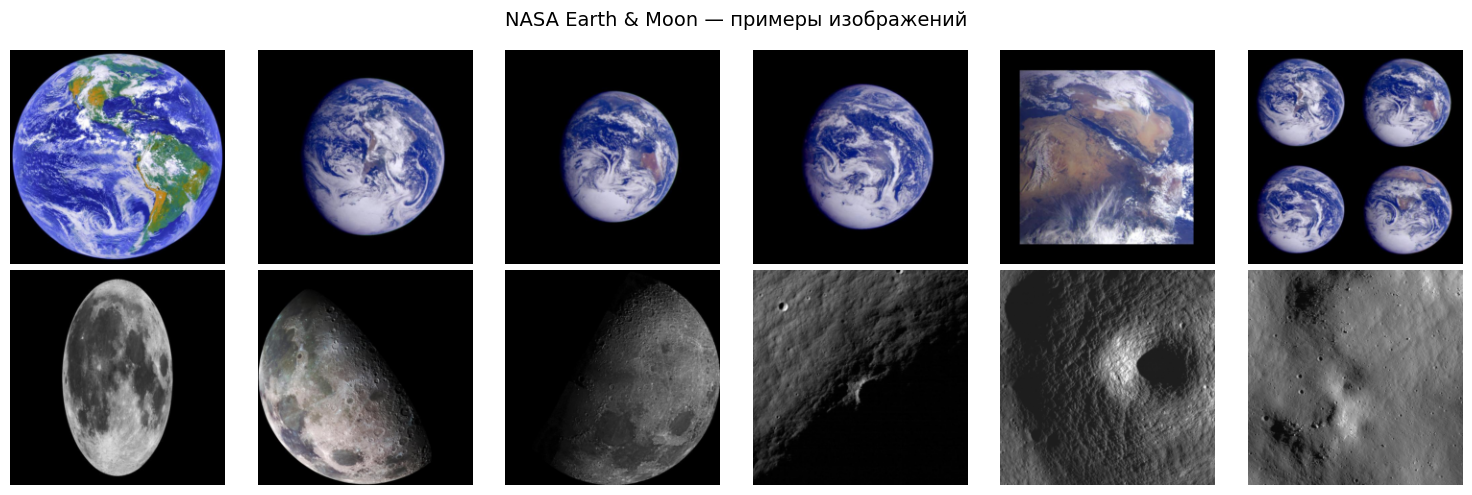

In [2]:
import kagglehub

# Загрузка датасета
dataset_path = kagglehub.dataset_download('marwanmostafa222012/nasa-earth-and-moon-images-for-ml')
print(f'Скачано в: {dataset_path}')

# Ищем train/ и test/ директории (структура: .../train/Earth|Moon, .../test/Earth|Moon)
train_dir, test_dir = None, None
for root, dirs, _ in os.walk(dataset_path):
    for d in dirs:
        candidate = os.path.join(root, d)
        subdirs = [s for s in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, s))]
        if len(subdirs) >= 2:
            if d.lower() == 'train' and train_dir is None:
                train_dir = candidate
            elif d.lower() == 'test' and test_dir is None:
                test_dir = candidate
    if train_dir and test_dir:
        break

# Если нет явного train/test — берём единую папку и делим сами
if train_dir is None:
    for root, dirs, _ in os.walk(dataset_path):
        if len(dirs) < 2:
            continue
        has_imgs = sum(1 for d in dirs
                       for f in os.listdir(os.path.join(root, d))
                       if f.lower().endswith(('.jpg','.jpeg','.png')))
        if has_imgs > 0:
            train_dir = root
            break

print(f'Train dir: {train_dir}')
print(f'Test dir:  {test_dir}')

# Статистика
for name, path in [('Train', train_dir), ('Test', test_dir)]:
    if path is None:
        continue
    for cls in sorted(os.listdir(path)):
        cpath = os.path.join(path, cls)
        if os.path.isdir(cpath):
            n = len([f for f in os.listdir(cpath) if os.path.isfile(os.path.join(cpath, f))])
            print(f'  {name}/{cls}: {n} изображений')

# ---- Трансформации ----
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ---- Создаём датасеты ----
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)

if test_dir is not None:
    val_dataset = datasets.ImageFolder(root=test_dir, transform=val_transform)
else:
    # Fallback: делим train 80/20
    n = len(train_dataset)
    perm = np.random.permutation(n)
    split = int(0.8 * n)
    ds_val_raw = datasets.ImageFolder(root=train_dir, transform=val_transform)
    train_dataset = Subset(train_dataset, perm[:split].tolist())
    val_dataset = Subset(ds_val_raw, perm[split:].tolist())

BATCH = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH, shuffle=False, num_workers=2)

class_names = datasets.ImageFolder(root=train_dir).classes
print(f'\nКлассы: {class_names}')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')

# ---- Визуализация примеров ----
vis_tf = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
vis_ds = datasets.ImageFolder(root=train_dir, transform=vis_tf)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
shown = {0: 0, 1: 0}
for i in range(len(vis_ds)):
    img, lbl = vis_ds[i]
    if shown[lbl] < 6:
        axes[lbl, shown[lbl]].imshow(img.permute(1, 2, 0).clamp(0, 1))
        axes[lbl, shown[lbl]].axis('off')
        shown[lbl] += 1
    if all(v >= 6 for v in shown.values()):
        break

for idx, name in enumerate(vis_ds.classes):
    axes[idx, 0].set_ylabel(name, fontsize=12, rotation=0, labelpad=50)

plt.suptitle('NASA Earth & Moon — примеры изображений', fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
# ---- Универсальная функция для эпохи обучения/оценки ----
def run_epoch(model, loader, criterion, optimizer=None):
    """Эпоха обучения (optimizer != None) или валидации."""
    training = optimizer is not None
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total


# ---- Feature Extraction: ResNet18 ----
model_fe = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Замораживаем все параметры
for p in model_fe.parameters():
    p.requires_grad = False

# Заменяем классификатор на новый (2 класса: Earth, Moon)
in_feat = model_fe.fc.in_features
model_fe.fc = nn.Linear(in_feat, 2)
model_fe = model_fe.to(device)

total_p = sum(p.numel() for p in model_fe.parameters())
train_p = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f'Всего параметров:     {total_p:,}')
print(f'Обучаемых параметров: {train_p:,}')
print(f'Заморожено:           {total_p - train_p:,}')

# ---- Обучение ----
criterion = nn.CrossEntropyLoss()
opt_fe = optim.Adam(model_fe.fc.parameters(), lr=1e-3)

N_EPOCHS = 10
hist_fe = {'tr_loss': [], 'tr_acc': [], 'va_loss': [], 'va_acc': []}

print('\n--- Обучение Feature Extraction ---')
for ep in range(N_EPOCHS):
    tl, ta = run_epoch(model_fe, train_loader, criterion, opt_fe)
    vl, va = run_epoch(model_fe, val_loader, criterion)
    hist_fe['tr_loss'].append(tl)
    hist_fe['tr_acc'].append(ta)
    hist_fe['va_loss'].append(vl)
    hist_fe['va_acc'].append(va)
    print(f'  Эпоха {ep+1}/{N_EPOCHS} | '
          f'Train: loss={tl:.4f} acc={ta:.4f} | '
          f'Val: loss={vl:.4f} acc={va:.4f}')

print(f'\nFE итоговая val accuracy: {hist_fe["va_acc"][-1]:.4f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Всего параметров:     11,177,538
Обучаемых параметров: 1,026
Заморожено:           11,176,512

--- Обучение Feature Extraction ---
  Эпоха 1/10 | Train: loss=0.7911 acc=0.5250 | Val: loss=0.7802 acc=0.4000
  Эпоха 2/10 | Train: loss=0.6293 acc=0.6250 | Val: loss=0.7947 acc=0.5000
  Эпоха 3/10 | Train: loss=0.5144 acc=0.8500 | Val: loss=0.6914 acc=0.6000
  Эпоха 4/10 | Train: loss=0.4219 acc=0.9250 | Val: loss=0.5942 acc=0.8000
  Эпоха 5/10 | Train: loss=0.4133 acc=0.8750 | Val: loss=0.5155 acc=0.9000
  Эпоха 6/10 | Train: loss=0.3493 acc=0.9000 | Val: loss=0.4558 acc=0.9000
  Эпоха 7/10 | Train: loss=0.3205 acc=0.9500 | Val: loss=0.4183 acc=0.9000
  Эпоха 8/10 | Train: loss=0.2704 acc=1.0000 | Val: loss=0.4021 acc=0.9000
  Эпоха 9/10 | Train: loss=0.2778 acc=0.9500 | Val: loss=0.3657 acc=0.9000
  Эпоха 10/10 | Train: loss=0.2024 acc=0.9750 | Val: loss=0.3209 acc=0.9000

FE итоговая val accuracy: 0.9000


---
## Задача 2. Fine-tuning с дифференцированными learning rates

**Постановка:** Разморозить все слои ResNet18 и дообучить модель на целевом датасете. Для предобученных слоёв используется пониженный learning rate, чтобы не разрушить полезные признаки ImageNet.

**Теория:** Fine-tuning позволяет адаптировать высокоуровневые признаки под специфику задачи. Learning rate для backbone ставится в 10–100 раз меньше, чем для нового классификатора, чтобы предобученные фильтры обновлялись плавно.


Обучаемых параметров (Fine-tuning): 11,177,538
  backbone lr = 1e-5, classifier lr = 1e-3

--- Обучение Fine-tuning ---
  Эпоха 1/10 | Train: loss=0.7552 acc=0.5750 | Val: loss=0.5446 acc=0.8000
  Эпоха 2/10 | Train: loss=0.5349 acc=0.6750 | Val: loss=0.4524 acc=0.8000
  Эпоха 3/10 | Train: loss=0.3811 acc=0.9250 | Val: loss=0.3349 acc=0.9000
  Эпоха 4/10 | Train: loss=0.2424 acc=0.9500 | Val: loss=0.2847 acc=0.9000
  Эпоха 5/10 | Train: loss=0.1786 acc=1.0000 | Val: loss=0.2624 acc=0.9000
  Эпоха 6/10 | Train: loss=0.1364 acc=1.0000 | Val: loss=0.2453 acc=0.9000
  Эпоха 7/10 | Train: loss=0.1507 acc=0.9750 | Val: loss=0.2122 acc=0.9000
  Эпоха 8/10 | Train: loss=0.1454 acc=1.0000 | Val: loss=0.2162 acc=0.9000
  Эпоха 9/10 | Train: loss=0.0617 acc=1.0000 | Val: loss=0.1905 acc=0.9000
  Эпоха 10/10 | Train: loss=0.1767 acc=0.9500 | Val: loss=0.1656 acc=0.9000

FT итоговая val accuracy: 0.9000


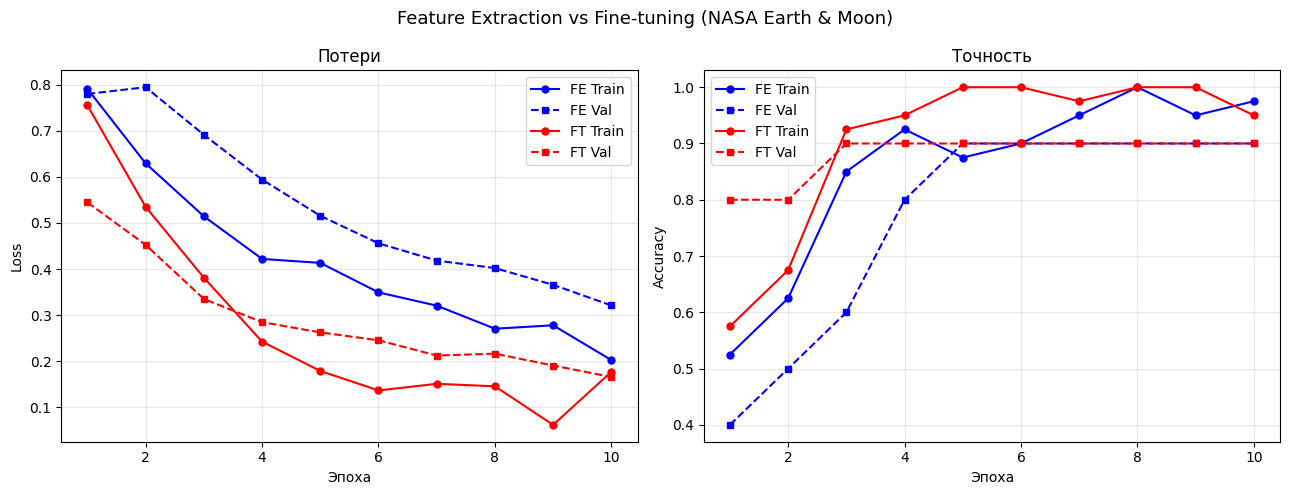


Метод                     Train Acc    Val Acc      Обучаемых params  
-------------------------------------------------------------------
Feature Extraction        0.9750       0.9000       1,026
Fine-tuning               0.9500       0.9000       11,177,538


In [4]:
# ---- Fine-tuning ----
model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_ft.fc = nn.Linear(model_ft.fc.in_features, 2)
model_ft = model_ft.to(device)

for p in model_ft.parameters():
    p.requires_grad = True

# Дифференцированные LR: backbone — 1e-5, classifier — 1e-3
fc_ids = set(id(p) for p in model_ft.fc.parameters())
backbone_params = [p for p in model_ft.parameters() if id(p) not in fc_ids]

opt_ft = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': model_ft.fc.parameters(), 'lr': 1e-3}
])

train_p_ft = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f'Обучаемых параметров (Fine-tuning): {train_p_ft:,}')
print(f'  backbone lr = 1e-5, classifier lr = 1e-3')

hist_ft = {'tr_loss': [], 'tr_acc': [], 'va_loss': [], 'va_acc': []}

print('\n--- Обучение Fine-tuning ---')
for ep in range(N_EPOCHS):
    tl, ta = run_epoch(model_ft, train_loader, criterion, opt_ft)
    vl, va = run_epoch(model_ft, val_loader, criterion)
    hist_ft['tr_loss'].append(tl)
    hist_ft['tr_acc'].append(ta)
    hist_ft['va_loss'].append(vl)
    hist_ft['va_acc'].append(va)
    print(f'  Эпоха {ep+1}/{N_EPOCHS} | '
          f'Train: loss={tl:.4f} acc={ta:.4f} | '
          f'Val: loss={vl:.4f} acc={va:.4f}')

print(f'\nFT итоговая val accuracy: {hist_ft["va_acc"][-1]:.4f}')

# ---- Сравнение FE vs FT ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ep_range = range(1, N_EPOCHS + 1)

ax1.plot(ep_range, hist_fe['tr_loss'], 'b-o', ms=5, label='FE Train')
ax1.plot(ep_range, hist_fe['va_loss'], 'b--s', ms=5, label='FE Val')
ax1.plot(ep_range, hist_ft['tr_loss'], 'r-o', ms=5, label='FT Train')
ax1.plot(ep_range, hist_ft['va_loss'], 'r--s', ms=5, label='FT Val')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Loss')
ax1.set_title('Потери'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_range, hist_fe['tr_acc'], 'b-o', ms=5, label='FE Train')
ax2.plot(ep_range, hist_fe['va_acc'], 'b--s', ms=5, label='FE Val')
ax2.plot(ep_range, hist_ft['tr_acc'], 'r-o', ms=5, label='FT Train')
ax2.plot(ep_range, hist_ft['va_acc'], 'r--s', ms=5, label='FT Val')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.set_title('Точность'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Feature Extraction vs Fine-tuning (NASA Earth & Moon)', fontsize=13)
plt.tight_layout()
plt.show()

# Итоговая таблица
print(f'\n{"Метод":<25} {"Train Acc":<12} {"Val Acc":<12} {"Обучаемых params":<18}')
print('-' * 67)
print(f'{"Feature Extraction":<25} {hist_fe["tr_acc"][-1]:<12.4f} {hist_fe["va_acc"][-1]:<12.4f} {train_p:,}')
print(f'{"Fine-tuning":<25} {hist_ft["tr_acc"][-1]:<12.4f} {hist_ft["va_acc"][-1]:<12.4f} {train_p_ft:,}')

---
## Задача 3. Реализация компонентов DANN

**Постановка:** Реализовать архитектуру DANN: Feature Extractor, Label Predictor, Domain Classifier и Gradient Reversal Layer (GRL) для адаптации MNIST → USPS.

**Теория:** GRL — ключевой элемент DANN. При прямом проходе он действует как тождественное отображение, при обратном — инвертирует градиент (умножает на $-\lambda$). Это заставляет Feature Extractor извлекать признаки, неразличимые для доменного классификатора, реализуя состязательное обучение в рамках единого прохода оптимизации.


In [5]:
# ==========================================
# Gradient Reversal Layer
# ==========================================
class GradReverse(Function):
    """Forward: identity. Backward: -λ * grad."""
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad):
        return -ctx.lam * grad, None

def gradient_reversal(x, lam=1.0):
    return GradReverse.apply(x, lam)


# ==========================================
# Feature Extractor (28×28, 1 канал)
# ==========================================
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 5),           # 28 → 24
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),               # 24 → 12
            nn.Conv2d(32, 48, 5),          # 12 → 8
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),               # 8 → 4
        )
        self.feat_dim = 48 * 4 * 4         # = 768

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)


# ==========================================
# Label Predictor (10 цифр)
# ==========================================
class LabelPredictor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 120),
            nn.BatchNorm1d(120),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(120, 84),
            nn.ReLU(inplace=True),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.net(x)


# ==========================================
# Domain Classifier (source=0 / target=1)
# ==========================================
class DomainClassifier(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 120),
            nn.BatchNorm1d(120),
            nn.ReLU(inplace=True),
            nn.Linear(120, 2)
        )

    def forward(self, x):
        return self.net(x)


# ==========================================
# Полная модель DANN
# ==========================================
class DANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = FeatureExtractor()
        dim = self.features.feat_dim
        self.classifier = LabelPredictor(dim)
        self.discriminator = DomainClassifier(dim)

    def forward(self, x, lam=1.0):
        feat = self.features(x)
        cls_out = self.classifier(feat)
        dom_out = self.discriminator(gradient_reversal(feat, lam))
        return cls_out, dom_out


# ---- Проверка ----
dann = DANN().to(device)
n_params = sum(p.numel() for p in dann.parameters())

print(f'=== Архитектура DANN ===')
print(f'Feature dim: {dann.features.feat_dim}')
print(f'Всего параметров: {n_params:,}')

dummy = torch.randn(2, 1, 28, 28).to(device)
c_out, d_out = dann(dummy, lam=0.5)
print(f'\nForward pass: вход {dummy.shape} → class {c_out.shape}, domain {d_out.shape}')

print(f'\nFeature Extractor:\n{dann.features}')
print(f'\nLabel Predictor:\n{dann.classifier}')
print(f'\nDomain Classifier:\n{dann.discriminator}')


=== Архитектура DANN ===
Feature dim: 768
Всего параметров: 235,736

Forward pass: вход torch.Size([2, 1, 28, 28]) → class torch.Size([2, 10]), domain torch.Size([2, 2])

Feature Extractor:
FeatureExtractor(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 48, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

Label Predictor:
LabelPredictor(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=120, bias=True)
    (1): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dr

---
## Задача 4. Обучение DANN (MNIST → USPS)

**Постановка:** Реализовать цикл обучения DANN, одновременно использующий размеченные данные исходного домена (MNIST) и неразмеченные данные целевого домена (USPS).

**Теория:** DANN минимизирует две потери: классификации меток (на source) и классификации доменов (на обоих). Параметр $\lambda$ возрастает по расписанию $\lambda = \frac{2}{1 + e^{-10p}} - 1$, где $p = \text{epoch} / \text{total\_epochs}$, обеспечивая плавное включение состязательного сигнала.


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]
100%|██████████| 6.58M/6.58M [00:00<00:00, 6.66MB/s]
100%|██████████| 1.83M/1.83M [00:00<00:00, 2.49MB/s]


MNIST — train: 60000, test: 10000
USPS  — train: 7291, test: 2007


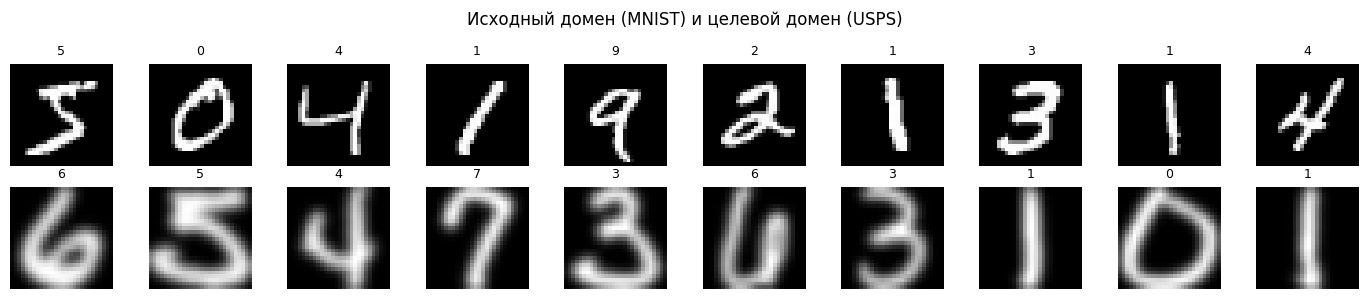

In [6]:
# ---- Загрузка MNIST и USPS ----
tf_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

tf_usps = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_train = datasets.MNIST('./data', train=True, download=True, transform=tf_mnist)
mnist_test = datasets.MNIST('./data', train=False, download=True, transform=tf_mnist)
usps_train = datasets.USPS('./data', train=True, download=True, transform=tf_usps)
usps_test = datasets.USPS('./data', train=False, download=True, transform=tf_usps)

print(f'MNIST — train: {len(mnist_train)}, test: {len(mnist_test)}')
print(f'USPS  — train: {len(usps_train)}, test: {len(usps_test)}')

BS_DANN = 128
src_train_loader = DataLoader(mnist_train, batch_size=BS_DANN, shuffle=True,
                              num_workers=2, drop_last=True)
tgt_train_loader = DataLoader(usps_train, batch_size=BS_DANN, shuffle=True,
                              num_workers=2, drop_last=True)
src_test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False, num_workers=2)
tgt_test_loader = DataLoader(usps_test, batch_size=256, shuffle=False, num_workers=2)

# ---- Визуализация примеров из двух доменов ----
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    img_m, lbl_m = mnist_train[i]
    axes[0, i].imshow(img_m.squeeze(), cmap='gray')
    axes[0, i].set_title(str(lbl_m), fontsize=9)
    axes[0, i].axis('off')

    img_u, lbl_u = usps_train[i]
    axes[1, i].imshow(img_u.squeeze(), cmap='gray')
    axes[1, i].set_title(str(lbl_u), fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('MNIST', fontsize=11, rotation=0, labelpad=35)
axes[1, 0].set_ylabel('USPS', fontsize=11, rotation=0, labelpad=35)
plt.suptitle('Исходный домен (MNIST) и целевой домен (USPS)', fontsize=12)
plt.tight_layout()
plt.show()


In [7]:
def eval_accuracy(model, loader):
    """Точность label predictor."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits, _ = model(X, lam=0.0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total


# ---- Обучение DANN ----
dann = DANN().to(device)
opt_dann = optim.Adam(dann.parameters(), lr=5e-4, weight_decay=1e-4)
ce_cls = nn.CrossEntropyLoss()
ce_dom = nn.CrossEntropyLoss()

DANN_EPOCHS = 20
hist_dann = defaultdict(list)

print('=== Обучение DANN (MNIST → USPS) ===\n')

for epoch in range(DANN_EPOCHS):
    dann.train()

    # Расписание λ: плавный рост от 0 до 1
    p = epoch / DANN_EPOCHS
    lam = float(2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0)

    losses_cls, losses_dom, losses_tot = [], [], []

    for (src_x, src_y), (tgt_x, _) in zip(src_train_loader, tgt_train_loader):
        src_x, src_y = src_x.to(device), src_y.to(device)
        tgt_x = tgt_x.to(device)

        combined = torch.cat([src_x, tgt_x])
        dom_labels = torch.cat([
            torch.zeros(src_x.size(0), dtype=torch.long),
            torch.ones(tgt_x.size(0), dtype=torch.long)
        ]).to(device)

        cls_out, dom_out = dann(combined, lam=lam)

        loss_cls = ce_cls(cls_out[:src_x.size(0)], src_y)
        loss_dom = ce_dom(dom_out, dom_labels)
        loss = loss_cls + loss_dom

        opt_dann.zero_grad()
        loss.backward()
        opt_dann.step()

        losses_cls.append(loss_cls.item())
        losses_dom.append(loss_dom.item())
        losses_tot.append(loss.item())

    src_acc = eval_accuracy(dann, src_test_loader)
    tgt_acc = eval_accuracy(dann, tgt_test_loader)

    hist_dann['loss_cls'].append(np.mean(losses_cls))
    hist_dann['loss_dom'].append(np.mean(losses_dom))
    hist_dann['loss_tot'].append(np.mean(losses_tot))
    hist_dann['src_acc'].append(src_acc)
    hist_dann['tgt_acc'].append(tgt_acc)
    hist_dann['lam'].append(lam)

    print(f'Epoch {epoch+1:2d}/{DANN_EPOCHS} | λ={lam:.3f} | '
          f'L_cls={np.mean(losses_cls):.4f} L_dom={np.mean(losses_dom):.4f} | '
          f'MNIST={src_acc:.4f} USPS={tgt_acc:.4f}')

=== Обучение DANN (MNIST → USPS) ===

Epoch  1/20 | λ=0.000 | L_cls=1.0371 L_dom=0.0612 | MNIST=0.9449 USPS=0.5745
Epoch  2/20 | λ=0.245 | L_cls=0.2054 L_dom=0.0089 | MNIST=0.9697 USPS=0.5630
Epoch  3/20 | λ=0.462 | L_cls=0.1275 L_dom=0.0046 | MNIST=0.9768 USPS=0.6398
Epoch  4/20 | λ=0.635 | L_cls=0.0914 L_dom=0.0028 | MNIST=0.9715 USPS=0.6139
Epoch  5/20 | λ=0.762 | L_cls=0.0906 L_dom=0.0022 | MNIST=0.9754 USPS=0.7524
Epoch  6/20 | λ=0.848 | L_cls=0.0716 L_dom=0.0016 | MNIST=0.9869 USPS=0.7688
Epoch  7/20 | λ=0.905 | L_cls=0.0621 L_dom=0.0012 | MNIST=0.9827 USPS=0.7444
Epoch  8/20 | λ=0.941 | L_cls=0.0552 L_dom=0.0010 | MNIST=0.9796 USPS=0.7937
Epoch  9/20 | λ=0.964 | L_cls=0.0631 L_dom=0.0009 | MNIST=0.9880 USPS=0.8017
Epoch 10/20 | λ=0.978 | L_cls=0.0508 L_dom=0.0009 | MNIST=0.9818 USPS=0.8122
Epoch 11/20 | λ=0.987 | L_cls=0.0531 L_dom=0.0007 | MNIST=0.9887 USPS=0.8271
Epoch 12/20 | λ=0.992 | L_cls=0.0473 L_dom=0.0007 | MNIST=0.9883 USPS=0.7952
Epoch 13/20 | λ=0.995 | L_cls=0.0417 L

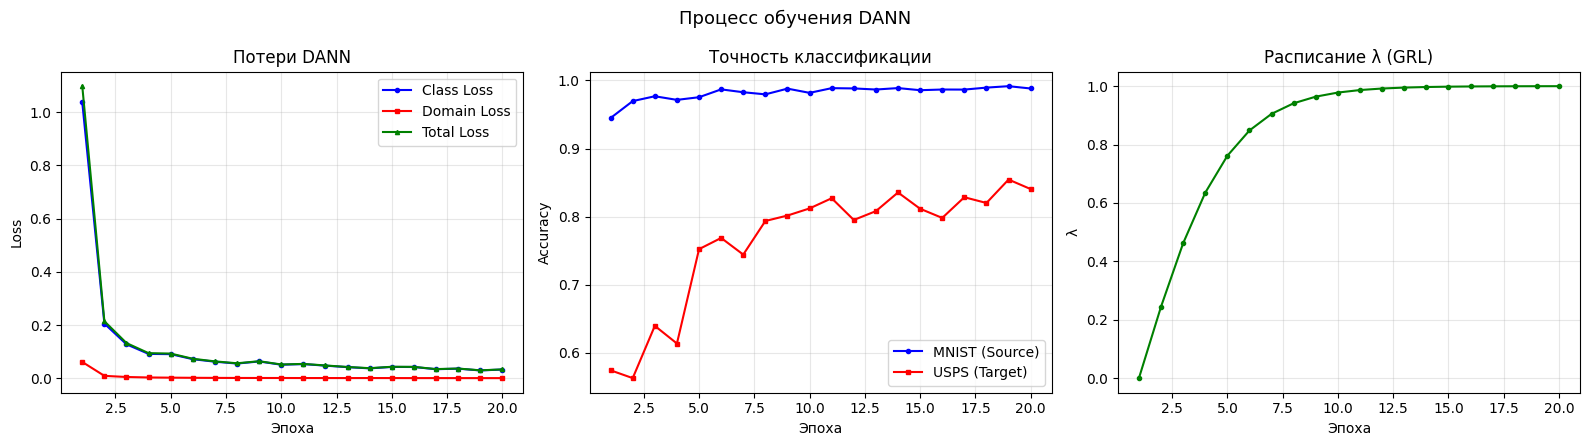

In [8]:
# ---- Визуализация обучения DANN ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ep_range = range(1, DANN_EPOCHS + 1)

axes[0].plot(ep_range, hist_dann['loss_cls'], 'b-o', ms=3, label='Class Loss')
axes[0].plot(ep_range, hist_dann['loss_dom'], 'r-s', ms=3, label='Domain Loss')
axes[0].plot(ep_range, hist_dann['loss_tot'], 'g-^', ms=3, label='Total Loss')
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
axes[0].set_title('Потери DANN')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, hist_dann['src_acc'], 'b-o', ms=3, label='MNIST (Source)')
axes[1].plot(ep_range, hist_dann['tgt_acc'], 'r-s', ms=3, label='USPS (Target)')
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность классификации')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_range, hist_dann['lam'], 'g-o', ms=3)
axes[2].set_xlabel('Эпоха'); axes[2].set_ylabel('λ')
axes[2].set_title('Расписание λ (GRL)')
axes[2].grid(alpha=0.3)

plt.suptitle('Процесс обучения DANN', fontsize=13)
plt.tight_layout()
plt.show()

---
## Задача 5. Сравнительный анализ стратегий адаптации

**Постановка:** Сравнить три стратегии переноса знаний MNIST → USPS:
1. **Source-only** — модель обучена только на MNIST, тестируется на USPS без адаптации;
2. **Fine-tuning** — предобученная на MNIST модель дообучается на 20% размеченных данных USPS;
3. **DANN** — состязательная адаптация с неразмеченными данными USPS.


In [9]:
# ---- Простая CNN (аналог Feature Extractor + Label Predictor из DANN) ----
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 5),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 48, 5),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Linear(48 * 4 * 4, 120),
            nn.BatchNorm1d(120),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(120, 84),
            nn.ReLU(inplace=True),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x).view(x.size(0), -1)
        return self.head(x)


def train_cnn(model, loader, epochs=10, lr=1e-3):
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            crit(model(X), y).backward()
            opt.step()


def eval_cnn(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            correct += (model(X).argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total


# ========================================
# 1. Source-only
# ========================================
print('=== 1. Source-only (только MNIST) ===')
model_src = DigitCNN().to(device)
train_cnn(model_src, src_train_loader, epochs=10)

so_mnist = eval_cnn(model_src, src_test_loader)
so_usps = eval_cnn(model_src, tgt_test_loader)
print(f'  MNIST: {so_mnist:.4f}, USPS: {so_usps:.4f}')
print(f'  Domain gap: {so_mnist - so_usps:.4f}')

# ========================================
# 2. Fine-tuning на 20% USPS
# ========================================
print('\n=== 2. Fine-tuning (MNIST pretrained + 20% USPS) ===')

model_ft2 = copy.deepcopy(model_src)

n_ft = int(0.2 * len(usps_train))
ft_idx = np.random.permutation(len(usps_train))[:n_ft]
ft_subset = Subset(usps_train, ft_idx.tolist())
ft_loader2 = DataLoader(ft_subset, batch_size=64, shuffle=True, num_workers=2)
print(f'  Используется {n_ft} изображений USPS')

# Дифференцированный LR
head_ids = set(id(p) for p in model_ft2.head.parameters())
opt_ft2 = optim.Adam([
    {'params': [p for p in model_ft2.parameters() if id(p) not in head_ids], 'lr': 1e-5},
    {'params': model_ft2.head.parameters(), 'lr': 1e-3}
])
crit_ft2 = nn.CrossEntropyLoss()

for _ in range(10):
    model_ft2.train()
    for X, y in ft_loader2:
        X, y = X.to(device), y.to(device)
        opt_ft2.zero_grad()
        crit_ft2(model_ft2(X), y).backward()
        opt_ft2.step()

ft_mnist = eval_cnn(model_ft2, src_test_loader)
ft_usps = eval_cnn(model_ft2, tgt_test_loader)
print(f'  MNIST: {ft_mnist:.4f}, USPS: {ft_usps:.4f}')


=== 1. Source-only (только MNIST) ===


  MNIST: 0.9918, USPS: 0.1878
  Domain gap: 0.8040

=== 2. Fine-tuning (MNIST pretrained + 20% USPS) ===
  Используется 1458 изображений USPS
  MNIST: 0.6644, USPS: 0.9527


=== 3. DANN (состязательная адаптация) ===
  MNIST: 0.9882, USPS: 0.8406

Стратегия                           MNIST (Source)     USPS (Target)     
----------------------------------------------------------------------
1. Source-only                      0.9918             0.1878            
2. Fine-tuning (20% USPS)           0.6644             0.9527            
3. DANN (adversarial)               0.9882             0.8406            


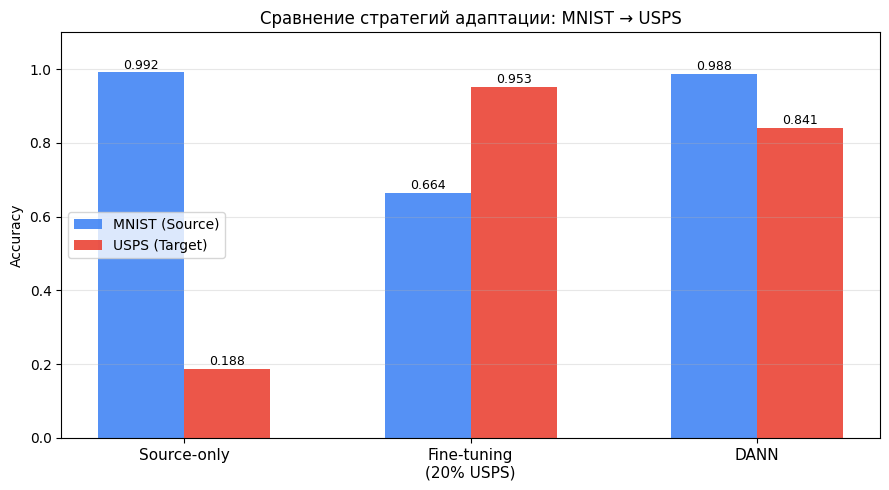

In [10]:
# ========================================
# 3. DANN (результаты из задачи 4)
# ========================================
dann_mnist = hist_dann['src_acc'][-1]
dann_usps = hist_dann['tgt_acc'][-1]

print('=== 3. DANN (состязательная адаптация) ===')
print(f'  MNIST: {dann_mnist:.4f}, USPS: {dann_usps:.4f}')

# ========================================
# Итоговая таблица
# ========================================
print(f'\n{"="*70}')
print(f'{"Стратегия":<35} {"MNIST (Source)":<18} {"USPS (Target)":<18}')
print(f'{"-"*70}')
print(f'{"1. Source-only":<35} {so_mnist:<18.4f} {so_usps:<18.4f}')
print(f'{"2. Fine-tuning (20% USPS)":<35} {ft_mnist:<18.4f} {ft_usps:<18.4f}')
print(f'{"3. DANN (adversarial)":<35} {dann_mnist:<18.4f} {dann_usps:<18.4f}')
print(f'{"="*70}')

# ---- Визуализация ----
fig, ax = plt.subplots(figsize=(9, 5))

strategies = ['Source-only', 'Fine-tuning\n(20% USPS)', 'DANN']
source_accs = [so_mnist, ft_mnist, dann_mnist]
target_accs = [so_usps, ft_usps, dann_usps]

x = np.arange(len(strategies))
w = 0.3

bars_s = ax.bar(x - w/2, source_accs, w, label='MNIST (Source)', color='#4285F4', alpha=0.9)
bars_t = ax.bar(x + w/2, target_accs, w, label='USPS (Target)', color='#EA4335', alpha=0.9)

for bar in bars_s:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение стратегий адаптации: MNIST → USPS')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---
## Выводы

1. **Feature Extraction** — заморозка предобученных слоёв ResNet18 и обучение только нового классификатора обеспечивает быструю сходимость на задаче Earth vs Moon. Метод эффективен при ограниченном объёме данных, так как минимизирует риск переобучения.

2. **Fine-tuning** — разморозка всех слоёв с дифференцированными learning rates (backbone: 1e-5, classifier: 1e-3) позволяет адаптировать высокоуровневые признаки ImageNet под специфику спутниковых снимков, что даёт прирост точности по сравнению с Feature Extraction.

3. **DANN** — Gradient Reversal Layer инвертирует градиент перед Domain Classifier, вынуждая Feature Extractor порождать доменно-инвариантные представления. В результате модель учится не различать MNIST и USPS, сохраняя при этом классификационную способность.

4. **Сравнительный анализ:**
   - **Source-only** показывает существенный domain gap: высокая точность на MNIST и значительное падение на USPS — это количественная мера сдвига доменов.
   - **Fine-tuning** на 20% размеченных данных USPS резко сокращает разрыв, но требует аннотированных целевых данных.
   - **DANN** повышает точность на целевом домене *без разметки*, используя только неразмеченные изображения USPS.

5. Плавное расписание $\lambda$ (sigmoid schedule) критически важно: резкий состязательный сигнал на ранних эпохах может дестабилизировать оптимизацию Feature Extractor.
